In [48]:
#imports
import os
import sys
import shutil
import tkinter
from pathlib import Path
from tkinter import filedialog

import numpy as np
import pandas as pd
from pandas import DataFrame
import matplotlib.pyplot as plt
from IPython.display import FileLink

np.set_printoptions(threshold=np.inf)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import csv

# Reuse the validated pipeline math from src/Python/workflow_utils.py instead of
# recomputing rigid-transform inversion by hand in this notebook. pyomeca's
# Rototrans.from_transposed_rototrans (used directly here previously) silently
# fails to invert a Rototrans built from a raw numpy array -- see
# workflow_utils.py's _invert_rigid_pose for the verified fix.
SRC_PYTHON_DIR = os.path.normpath(os.path.join(os.path.abspath(''), '..', 'src', 'Python'))
if SRC_PYTHON_DIR not in sys.path:
    sys.path.insert(0, SRC_PYTHON_DIR)

from opensim_scaling import run_scale_tool, write_scale_setup_xml
from workflow_utils import (
    absolute_segment_angles,
    build_mot_dataframe,
    get_frame_rate_and_count,
    get_rotation_labels,
    get_segment_pose,
    load_theia_c3d,
    relative_segment_angles,
    trim_dataframe,
    validate_mot_dataframe,
    write_mot,
    write_static_trc_from_c3d,
)

# Resolve stable output locations in the notebook folder.
REPO_ROOT = Path(SRC_PYTHON_DIR).resolve().parents[1]
NOTEBOOK_DIR = REPO_ROOT / 'notebook'
NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# -------------------------------------------------------------------------
# USER SETUP — run this cell first, before anything else
# -------------------------------------------------------------------------
# Step A (optional): select a dedicated static C3D file (e.g. Static.c3d).
#   If you don't have one, cancel/close the dialog — the dynamic trial will
#   be used instead and select_frame below will determine which frame is used.
#
# Step B: set select_frame to a frame where the subject is standing still.
#   This is only used when no static file is selected.
# -------------------------------------------------------------------------

# USER: change this to the frame where your subject is standing still
select_frame = 300  # <-- adjust to match your data

root = tkinter.Tk()
root.withdraw()
root.call('wm', 'attributes', '.', '-topmost', True)

static_c3d_path = filedialog.askopenfilename(
    title='(Optional) Select static C3D — cancel to use dynamic trial frames'
)

if static_c3d_path:
    static_c3d_path = os.path.normpath(static_c3d_path)
    c_static = load_theia_c3d(static_c3d_path)
    has_static_file = True
    print(f"Static source: {static_c3d_path}")
else:
    has_static_file = False
    print(f"No static file selected — will use frame {select_frame} from dynamic trial")

Static source: D:\A_Work\Projects\Repos\Theia2OpenSim\sample_data\c3d_trials\Static.c3d


In [3]:
# USER: select your DYNAMIC trial C3D file (e.g. Walking.c3d)
root = tkinter.Tk()
root.withdraw()
root.call('wm', 'attributes', '.', '-topmost', True)

c3d_file = filedialog.askopenfilename(title='Select dynamic trial C3D (e.g. Walking.c3d)')
c3d_file = os.path.normpath(c3d_file)
c = load_theia_c3d(c3d_file)

if not has_static_file:
    c_static = c

In [4]:
# Find the sampling rate and total frame count from the C3D metadata.
frame_rate, total_frames = get_frame_rate_and_count(c)
frame_values = list(range(total_frames))

In [5]:
# Convert frame numbers to elapsed time in seconds.
def calculate_time_per_frame(frame_rate, total_frames):
    time_per_frame = 1 / frame_rate
    return [time_per_frame] * total_frames

individual_times = calculate_time_per_frame(frame_rate, total_frames)
time = np.round(np.array(frame_values) / frame_rate, 5)

In [6]:
# Get list of segment pose matricies
keysList = get_rotation_labels(c)

print(keysList)

['worldbody_4X4', 'pelvis_4X4', 'l_thigh_4X4', 'l_shank_4X4', 'l_foot_4X4', 'l_toes_4X4', 'r_thigh_4X4', 'r_shank_4X4', 'r_foot_4X4', 'r_toes_4X4', 'head_4X4', 'torso_4X4', 'l_uarm_4X4', 'l_larm_4X4', 'l_hand_4X4', 'r_uarm_4X4', 'r_larm_4X4', 'r_hand_4X4', 'pelvis_shifted_4X4']


In [7]:
# Get the pelvis pose matrix (workflow_utils cleans NaNs and scales translation to mm).
pelvis_4X4 = get_segment_pose(c, 'pelvis_4X4')

# Build the canonical motion table from the script pipeline so notebook plots
# and exports stay consistent with src/Python/run_pipeline.py.
pipeline_df = build_mot_dataframe(c)

time = pipeline_df['time'].to_numpy()
pelvistilt = pipeline_df['pelvis_tilt'].to_numpy()
pelvislist = pipeline_df['pelvis_list'].to_numpy()
pelvisrot = pipeline_df['pelvis_rotation'].to_numpy()
pelvis_tx = pipeline_df['pelvis_tx'].to_numpy()
pelvis_ty = pipeline_df['pelvis_ty'].to_numpy()
pelvis_tz = pipeline_df['pelvis_tz'].to_numpy()

# Keep pelvis_angles available for downstream plotting cells.
pelvis_angles = np.stack([pelvistilt, pelvislist, pelvisrot])[:, np.newaxis, :]

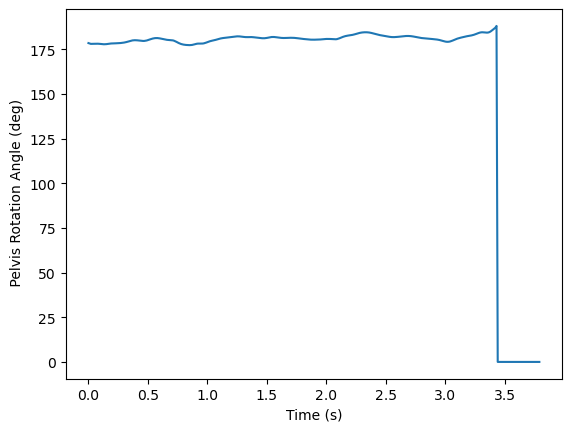

In [8]:
pelvisrot = pelvis_angles[2, 0, :]
plt.plot(time, pelvisrot)
plt.ylabel(" Pelvis Rotation Angle (deg)")
plt.xlabel("Time (s)")
plt.show()

pelvisrot = np.round(pelvisrot,2)

Text(0.5, 0, 'Time (s)')

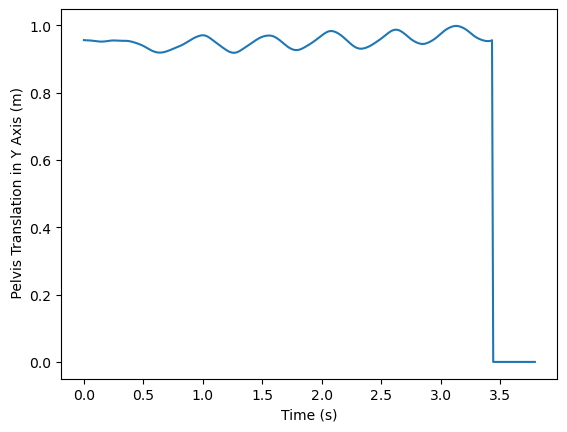

In [9]:
plt.plot(time, pelvis_ty)
pelvis_ty = np.round(pelvis_ty,2)
plt.ylabel(" Pelvis Translation in Y Axis (m)")
plt.xlabel("Time (s)")
#plt.xlim(0,1.49)
#print(pelvis_ty)

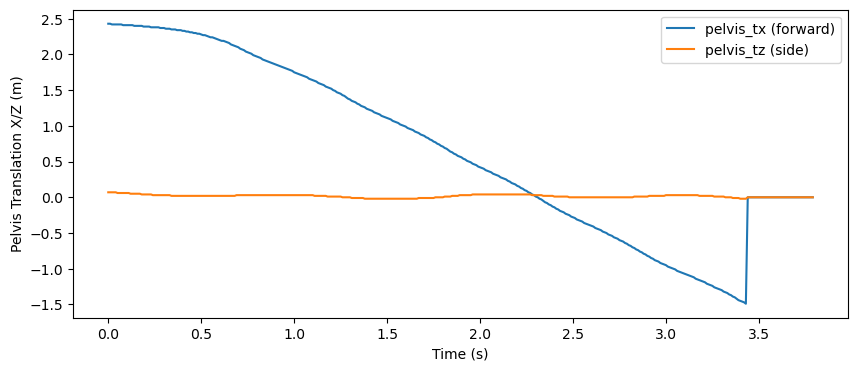

In [10]:
pelvis_tx = np.round(pelvis_tx, 2)
pelvis_tz = np.round(pelvis_tz, 2)

plt.figure(figsize=(10, 4))
plt.plot(time, pelvis_tx, label='pelvis_tx (forward)')
plt.plot(time, pelvis_tz, label='pelvis_tz (side)')
plt.ylabel("Pelvis Translation X/Z (m)")
plt.xlabel("Time (s)")
plt.legend()
plt.show()

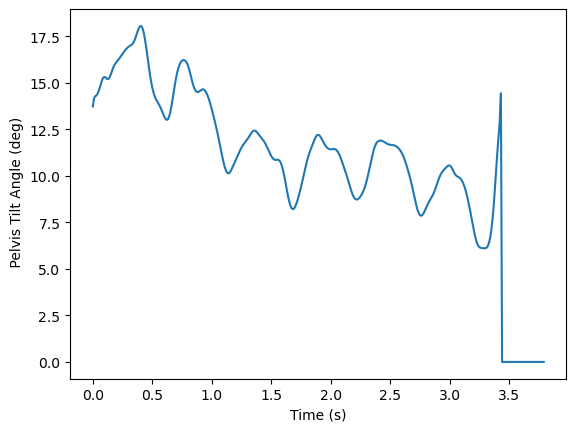

In [11]:
pelvistilt = pelvis_angles[0, 0, :]
plt.plot(time, pelvistilt)
plt.ylabel(" Pelvis Tilt Angle (deg)")
plt.xlabel("Time (s)")
plt.show()

pelvistilt = np.round(pelvistilt,2)

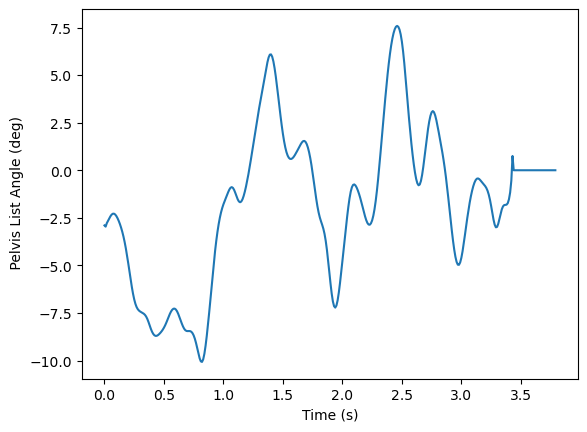

In [12]:
pelvislist = pelvis_angles[1, 0, :]
plt.plot(time, pelvislist)
plt.ylabel(" Pelvis List Angle (deg)")
plt.xlabel("Time (s)")
plt.show()

pelvislist = np.round(pelvislist,2)

In [13]:
torso_4X4 = get_segment_pose(c, 'torso_4X4')

# Lumbar motion is torso relative to pelvis, using the same sequence as the pipeline.
lumbar_angles = relative_segment_angles(pelvis_4X4, torso_4X4, sequence='zxy')

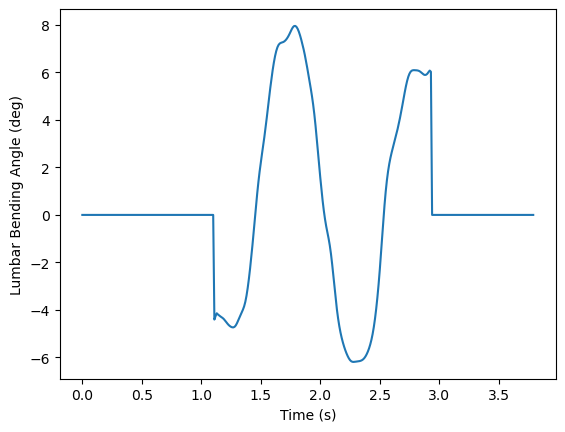

In [14]:
lumbarbending = lumbar_angles[0, 0, :]
plt.ylabel("Lumbar Bending Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time, lumbarbending)
plt.show()

lumbarbending = np.round(lumbarbending,2)

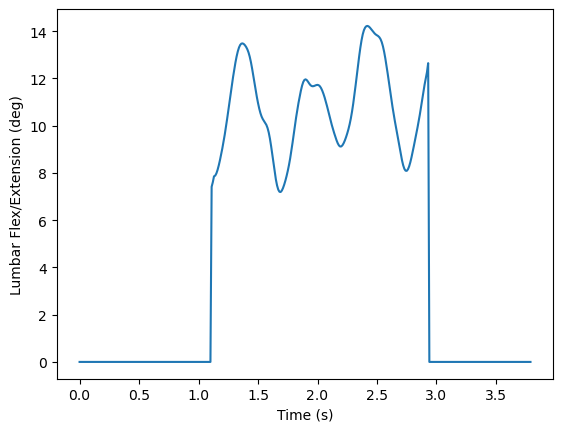

In [15]:
lumbarflex = lumbar_angles[1, 0, :]
plt.ylabel("Lumbar Flex/Extension (deg)")
plt.xlabel("Time (s)")
plt.plot(time, lumbarflex)
plt.show()

lumbarflex = np.round(lumbarflex,2)

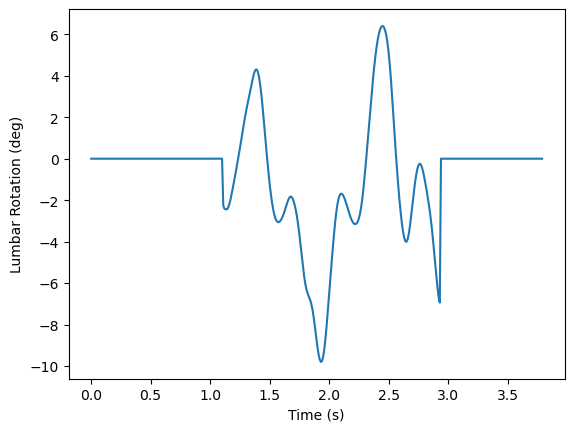

In [16]:
lumbarrot = lumbar_angles[2, 0, :]
plt.ylabel("Lumbar Rotation (deg)")
plt.xlabel("Time (s)")
plt.plot(time, lumbarrot)
plt.show()

lumbarrot = np.round(lumbarrot,2)

In [17]:
l_thigh_4X4 = get_segment_pose(c, 'l_thigh_4X4')
l_shank_4X4 = get_segment_pose(c, 'l_shank_4X4')

knee_angles_l = relative_segment_angles(l_thigh_4X4, l_shank_4X4)

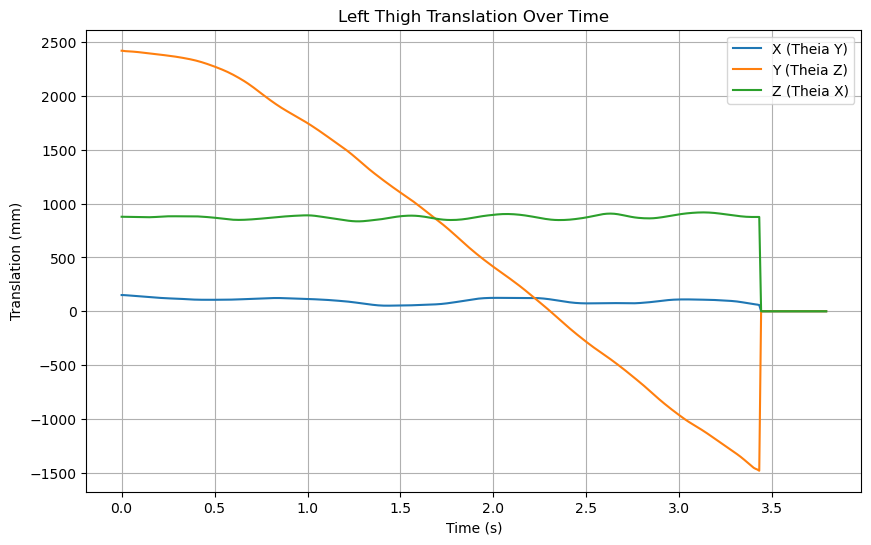

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Extract translations from l_thigh_4X4 (shape: [4, 4, N])
l_thigh_translations = l_thigh_4X4[:3, 3, :].T  # Shape: [N, 3] (x, y, z)

# Create a time array (assuming frame_rate and total_frames are defined)
time = np.arange(l_thigh_translations.shape[0]) / frame_rate

# Plot translations
plt.figure(figsize=(10, 6))
plt.plot(time, l_thigh_translations[:, 0], label='X (Theia Y)')
plt.plot(time, l_thigh_translations[:, 1], label='Y (Theia Z)')
plt.plot(time, l_thigh_translations[:, 2], label='Z (Theia X)')
plt.xlabel('Time (s)')
plt.ylabel('Translation (mm)')
plt.title('Left Thigh Translation Over Time')
plt.legend()
plt.grid(True)
plt.show()


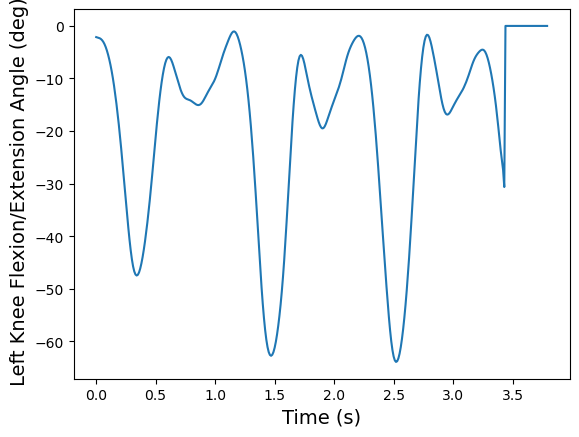

In [19]:
lkneeflex = knee_angles_l[0, 0, :]
plt.ylabel(" Left Knee Flexion/Extension Angle (deg)", fontsize=14)
plt.xlabel("Time (s)", fontsize=14)
plt.plot(time,lkneeflex)
plt.show()

lkneeflex = np.round(lkneeflex,2)

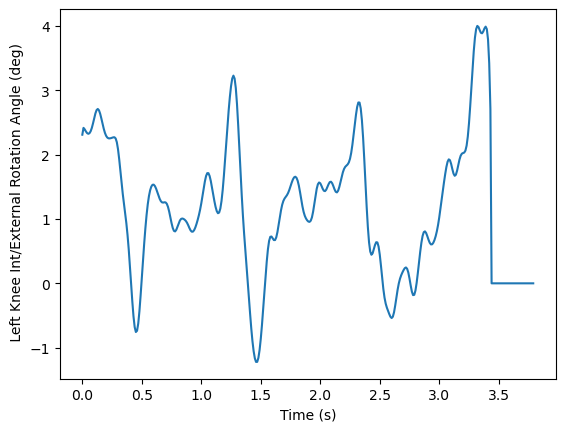

In [20]:
lkneerot = knee_angles_l[1, 0, :]
plt.ylabel(" Left Knee Int/External Rotation Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time, lkneerot)
plt.show()

lkneerot = np.round(lkneerot,2)

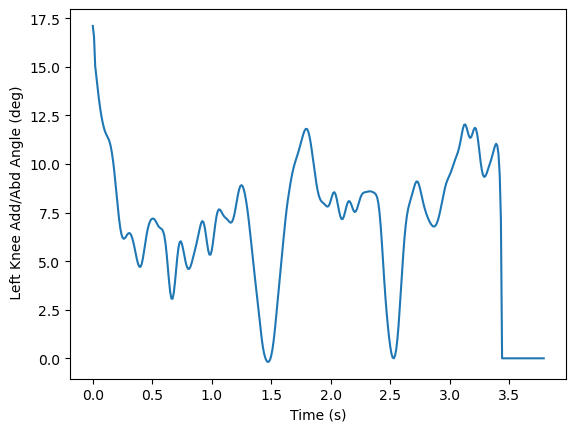

In [21]:
lkneeadd = knee_angles_l[2, 0, :]
plt.ylabel(" Left Knee Add/Abd Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time, lkneeadd)
plt.show()

lkneeadd = np.round(lkneeadd,2)

In [22]:
r_thigh_4X4 = get_segment_pose(c, 'r_thigh_4X4')
r_shank_4X4 = get_segment_pose(c, 'r_shank_4X4')

knee_angles_r = relative_segment_angles(r_thigh_4X4, r_shank_4X4)

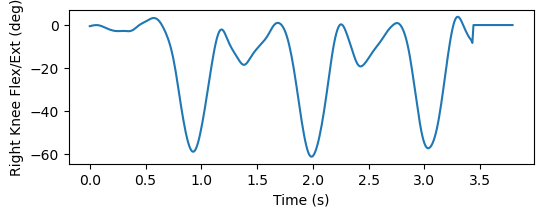

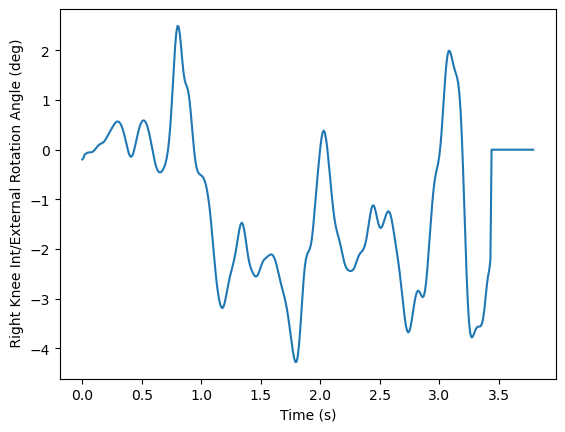

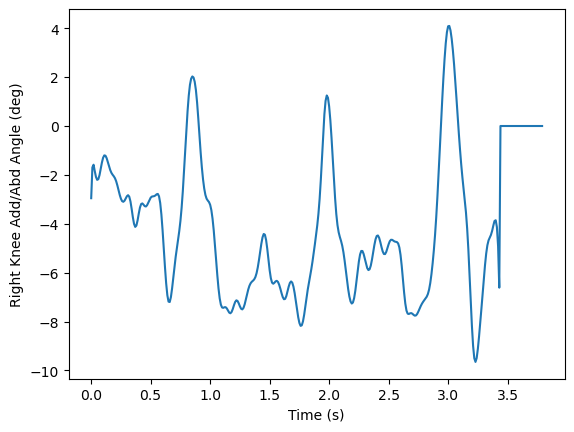

In [23]:
rkneeflex = knee_angles_r[0, 0, :]
plt.figure(figsize=(6, 2))  # Only applies to this plot
plt.ylabel("Right Knee Flex/Ext (deg)")
plt.xlabel("Time (s)")
plt.plot(time, rkneeflex)
plt.show()
rkneeflex = np.round(rkneeflex, 2)

rkneerot = knee_angles_r[1, 0, :]
plt.ylabel(" Right Knee Int/External Rotation Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time,rkneerot)
plt.show()
rkneerot = np.round(rkneerot,2)

rkneeadd = knee_angles_r[2, 0, :]
plt.ylabel("Right Knee Add/Abd Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time,rkneeadd)
plt.show()
rkneeadd = np.round(rkneeadd,2)

In [24]:
l_hip_angles = relative_segment_angles(pelvis_4X4, l_thigh_4X4)

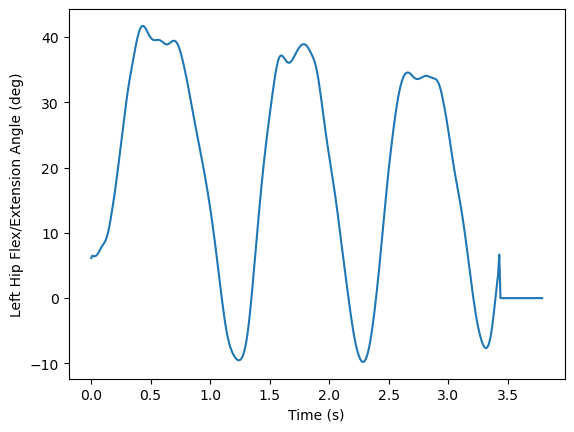

In [25]:
lhipflex = l_hip_angles[0, 0, :]
plt.ylabel("Left Hip Flex/Extension Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time,lhipflex)
plt.show()
lhipflex = np.round(lhipflex,2)

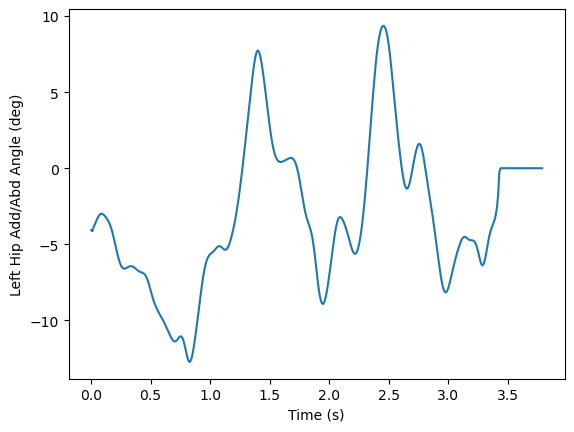

In [26]:
lhipadd = l_hip_angles[1, 0, :]
plt.ylabel("Left Hip Add/Abd Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time,lhipadd)
plt.show()
lhipadd = np.round(lhipadd,2)

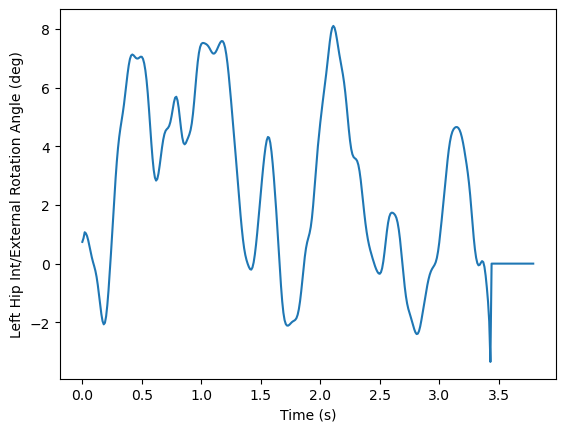

In [27]:
lhiprot = l_hip_angles[2, 0, :]
plt.ylabel("Left Hip Int/External Rotation Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time,lhiprot)
plt.show()
lhiprot = np.round(lhiprot,2)

In [28]:
r_hip_angles = relative_segment_angles(pelvis_4X4, r_thigh_4X4)

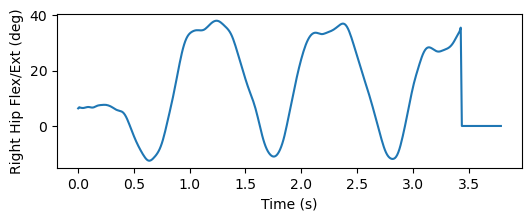

In [29]:
rhipflex = r_hip_angles[0, 0, :]
plt.figure(figsize=(6, 2))  # Only applies to this plot
plt.ylabel("Right Hip Flex/Ext (deg)")
plt.xlabel("Time (s)")
plt.plot(time,rhipflex)
plt.show()
rhipflex = np.round(rhipflex,2)

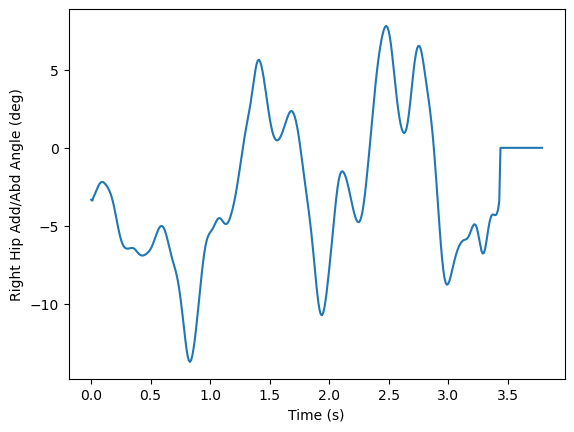

In [30]:
rhipadd = r_hip_angles[1, 0, :]
plt.ylabel("Right Hip Add/Abd Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time,rhipadd)
plt.show()
rhipadd = np.round(rhipadd,2)

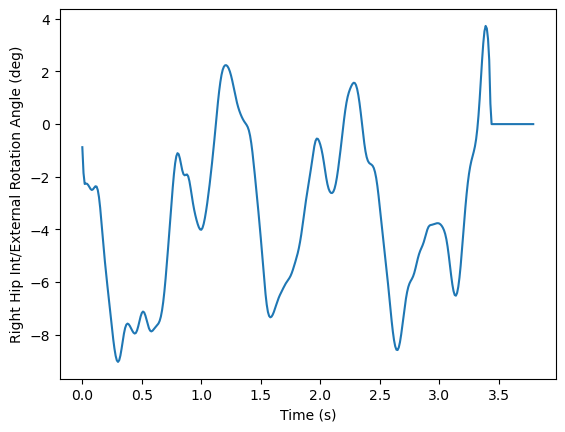

In [31]:
rhiprot = r_hip_angles[2, 0, :]
plt.ylabel("Right Hip Int/External Rotation Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time,rhiprot)
plt.show()
rhiprot = np.round(rhiprot,2)

In [32]:
l_foot_4X4 = get_segment_pose(c, 'l_foot_4X4')

ankle_angle_l = relative_segment_angles(l_shank_4X4, l_foot_4X4)

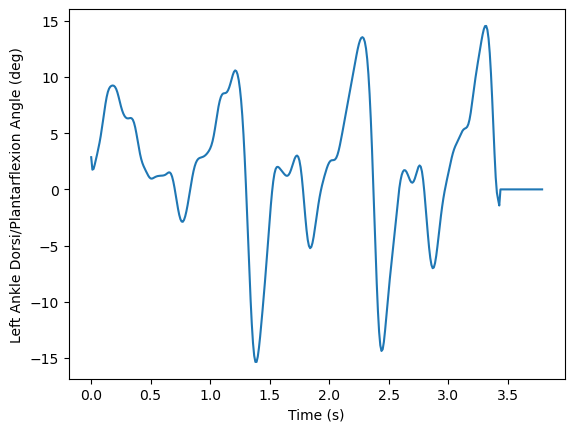

In [33]:
lankleflex = ankle_angle_l[0, 0, :]
plt.ylabel("Left Ankle Dorsi/Plantarflexion Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time,lankleflex)
plt.show()

lankleflex = np.round(lankleflex,2)

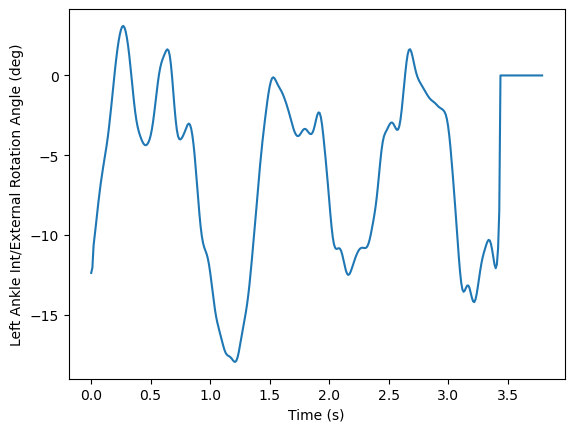

In [34]:
lanklerot = ankle_angle_l[2, 0, :]
plt.ylabel("Left Ankle Int/External Rotation Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time,lanklerot)
plt.show()
lanklerot = np.round(lanklerot,2)

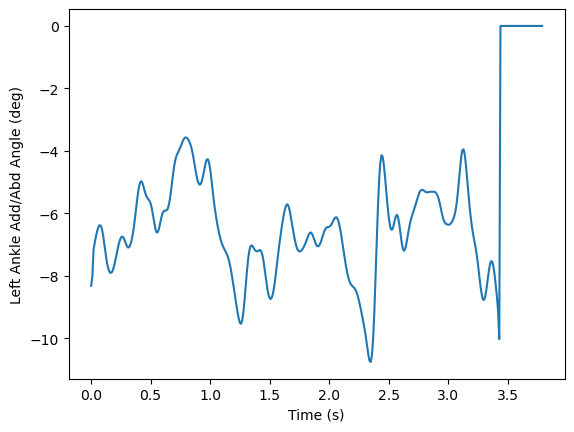

In [35]:
lankleadd = ankle_angle_l[1, 0, :]
plt.ylabel("Left Ankle Add/Abd Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time,lankleadd)
plt.show()
lankleadd = np.round(lankleadd,2)

In [36]:
r_foot_4X4 = get_segment_pose(c, 'r_foot_4X4')

ankle_angle_r = relative_segment_angles(r_shank_4X4, r_foot_4X4)

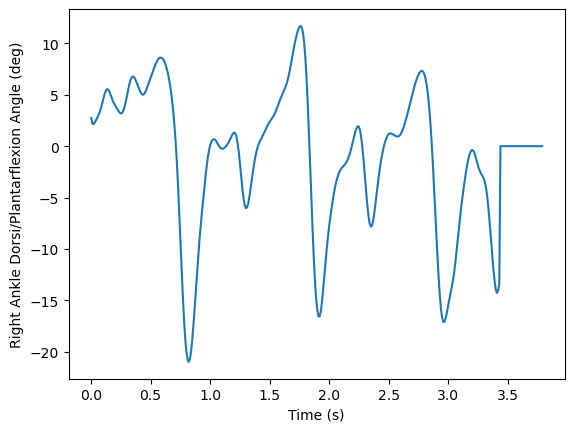

In [37]:
rankleflex = ankle_angle_r[0, 0, :]
plt.ylabel("Right Ankle Dorsi/Plantarflexion Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time,rankleflex)
plt.show()
rankleflex = np.round(rankleflex,2)

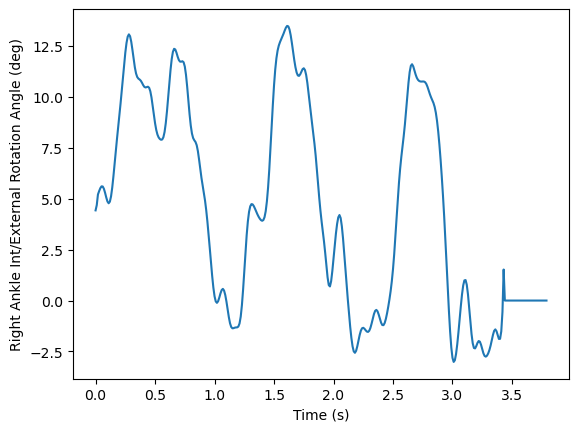

In [38]:
ranklerot = ankle_angle_r[2, 0, :]
plt.ylabel("Right Ankle Int/External Rotation Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time,ranklerot)
plt.show()
ranklerot = np.round(ranklerot,2)

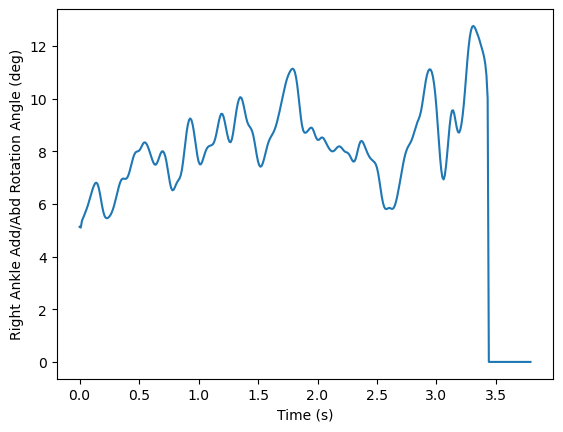

In [39]:
rankleadd = ankle_angle_r[1, 0, :]
plt.ylabel("Right Ankle Add/Abd Rotation Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time,rankleadd)
plt.show()
rankleadd = np.round(rankleadd,2)

In [40]:
r_toes_4X4 = get_segment_pose(c, 'r_toes_4X4')
l_toes_4X4 = get_segment_pose(c, 'l_toes_4X4')

In [42]:
# Build and export the OpenSim motion table using the same utilities as the
# script pipeline so notebook output stays in lockstep with run_pipeline.py.
pipeline_df = build_mot_dataframe(c)
issues = validate_mot_dataframe(pipeline_df)
if issues:
    raise RuntimeError("Cannot export MOT due to data issues: " + "; ".join(issues))

write_mot(pipeline_df, 'OS.mot')
print("Data saved to OS.mot")

FileLink('OS.mot')

Data saved to OS.mot


d:\A_Work\Projects\Repos\Theia2OpenSim\notebook\OS.mot

In [43]:
# Trim leading/trailing zero-only regions using the same utility as the script pipeline.
trimmed_df = trim_dataframe(pipeline_df, frame_rate=frame_rate)
issues = validate_mot_dataframe(trimmed_df)
if issues:
    raise RuntimeError("Cannot export trimmed MOT due to data issues: " + "; ".join(issues))

write_mot(trimmed_df, 'OS.mot')
print("Trimmed .mot file saved to: OS.mot")

FileLink('OS.mot')

Trimmed .mot file saved to: OS.mot


d:\A_Work\Projects\Repos\Theia2OpenSim\notebook\OS.mot

In [49]:
# Build the static .trc file using the resolved static source (c_static, set in
# the USER SETUP / dynamic-trial-selection cells above) and select_frame set at
# the top. This reuses workflow_utils.write_static_trc_from_c3d instead of the
# hand-rolled column layout used here previously, so the marker set/axis mapping
# stays in lockstep with the rest of the pipeline.
static_frame_indices = [select_frame]
repeat_static_frames = 6
static_trc_path = NOTEBOOK_DIR / 'Static.trc'

write_static_trc_from_c3d(
    c_static,
    output_path=static_trc_path,
    frame_indices=static_frame_indices,
    repeat_frames=repeat_static_frames,
)

FileLink(str(static_trc_path))

D:\A_Work\Projects\Repos\Theia2OpenSim\notebook\Static.trc

In [50]:
# Scale model and save outputs under the notebook folder, matching the script workflow.
scale_model_file = REPO_ROOT / 'sample_data' / 'gait2392_simbody.osim'
marker_set_file = REPO_ROOT / 'sample_data' / 'markerstheia.xml'
output_osim_path = NOTEBOOK_DIR / 'scaled_model.osim'
static_coords_path = NOTEBOOK_DIR / 'scaled_model_static_coords.mot'
setup_xml_path = NOTEBOOK_DIR / 'scaled_model_Scaling_Setup.xml'

static_df = build_mot_dataframe(c_static)
write_mot(static_df, static_coords_path)

static_frame_rate, _ = get_frame_rate_and_count(c_static)
time_range = (0.0, (repeat_static_frames - 1) / static_frame_rate)

write_scale_setup_xml(
    output_xml_path=setup_xml_path,
    model_file=scale_model_file,
    marker_set_file=marker_set_file,
    marker_file=static_trc_path,
    coordinate_file=static_coords_path,
    output_model_file=output_osim_path,
    time_range=time_range,
    mass=75.1646,
)

opensim_cmd = os.environ.get('OPENSIM_CMD') or shutil.which('opensim-cmd')
if not opensim_cmd:
    print('[SKIP] Scale Tool: opensim-cmd not found. Set OPENSIM_CMD or add opensim-cmd to PATH.')
else:
    result = run_scale_tool(setup_xml_path, output_osim_path, opensim_cmd=opensim_cmd)
    if result.success:
        print(f"[PASS] Wrote scaled model: {output_osim_path}")
        if result.marker_rms is not None:
            print(f"- Marker error: RMS = {result.marker_rms:.4f} m, max = {result.marker_max:.4f} m ({result.marker_max_name})")
        FileLink(str(output_osim_path))
    else:
        print('[FAIL] OpenSim Scale Tool did not complete successfully:')
        print(result.stdout)

print(f"Scale setup XML: {setup_xml_path}")
print(f"Static coords MOT: {static_coords_path}")

[PASS] Wrote scaled model: D:\A_Work\Projects\Repos\Theia2OpenSim\notebook\scaled_model.osim
- Marker error: RMS = 0.0791 m, max = 0.1641 m (LASIS)
Scale setup XML: D:\A_Work\Projects\Repos\Theia2OpenSim\notebook\scaled_model_Scaling_Setup.xml
Static coords MOT: D:\A_Work\Projects\Repos\Theia2OpenSim\notebook\scaled_model_static_coords.mot


In [47]:
import numpy as np
from scipy.io import savemat

# Assuming the following 4x4 matrices are defined in your code:
# pelvis_4X4, r_thigh_4X4, l_thigh_4X4, r_shank_4X4, l_shank_4X4, r_foot_4X4, l_foot_4X4, r_toes_4X4, l_toes_4X4

# Extract translations for all frames (not just frame 300)
joint_centers = {
    'PELVIS': pelvis_4X4[:3, 3, :].T,  # Shape: [N, 3] (x, y, z)
    'RFEMUR': r_thigh_4X4[:3, 3, :].T,   # Right ASIS
    'LFEMUR': l_thigh_4X4[:3, 3, :].T,   # Left ASIS
    'RTIB': r_shank_4X4[:3, 3, :].T,   # Right knee
    'LTIB': l_shank_4X4[:3, 3, :].T,   # Left knee
    'RFOOT': r_foot_4X4[:3, 3, :].T,   # Right ankle
    'LFOOT': l_foot_4X4[:3, 3, :].T,   # Left ankle
    'RTOE': r_toes_4X4[:3, 3, :].T,     # Right toe
    'LTOE': l_toes_4X4[:3, 3, :].T,     # Left toe
}

# Save to a .mat file
savemat('joint_centers.mat', joint_centers)

print("Joint centers saved to 'joint_centers.mat'")


Joint centers saved to 'joint_centers.mat'
